In [ ]:
  !pip install pandas numpy nltk scikit-learn imbalanced-learn gdown tensorflow emoji

<h1>Loading the data and checking the shape</h1>


In [ ]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/bbhanu014/dataset1/Mental-health-related-subreddits.csv")

display(df.head())

/tmp/ipykernel_17/418078251.py:2: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/bbhanu014/dataset1/Mental-health-related-subreddits.csv")


,Title,Text,Subreddit,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78
0,exposure does not work!,I have struggled with social anxiety from chil...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Panic attack? derealization? can't go to docto...,"Back in March (I know, a while ago D:), I woke...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,How long can a panic attack last?!,I've been withdrawing from medicines lately (e...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Stepping stones,"First time poster, long time lurker. \n\nI've ...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Coping with anxiety over climate change, on th...","Hi all,\n\nI made a throwaway account as my ma...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

In [ ]:
print(df.shape)
print(df.columns)
df.info()

(488738, 3)
Index(['Title', 'Text', 'Subreddit'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488738 entries, 0 to 488737
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Title      488608 non-null  object
 1   Text       488573 non-null  object
 2   Subreddit  488535 non-null  object
dtypes: object(3)
memory usage: 11.2+ MB


In [ ]:
df = df.dropna()

print(df.isnull().sum())

Title        0
Text         0
Subreddit    0
dtype: int64


In [ ]:
valid_labels = [
    "depression",
    "mentalhealth",
    "Anxiety",
    "bipolar",
    "BPD",
    "schizophrenia",
    "autism"
]

# normalize text (very important)
df["Subreddit"] = df["Subreddit"].astype(str).str.strip()

# keep only valid labels
df = df[df["Subreddit"].isin(valid_labels)]

df = df[df["Subreddit"] != "mentalhealth"]

df["Subreddit"].value_counts()

Subreddit
depression       258490
Anxiety           86242
bipolar           41490
BPD               38210
schizophrenia     17505
autism             7142
Name: count, dtype: int64

<h3>Text Length Analysis</h3>

In [ ]:
df["text_length"] = df["Text"].apply(lambda x: len(str(x).split()))

df["text_length"].describe()

count    449079.000000
mean        184.987488
std         224.415564
min           0.000000
25%          60.000000
50%         121.000000
75%         229.000000
max        6597.000000
Name: text_length, dtype: float64

<h3>Removing the Posts with 0 words</h3>

In [ ]:
df = df[df["text_length"] > 0]
print(df.shape)

(449000, 4)


<h3>Triming the long text</h3>

In [ ]:
def trim_text(text, max_words=500):
    words = str(text).split()
    return " ".join(words[:max_words])

df["Text"] = df["Text"].apply(trim_text)
df.shape

(449000, 4)

<h3>Merge Title + Text</h3>

In [ ]:
df["content"] = df["Title"] + " " + df["Text"]

<h3>Clean Text</h3>

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()  # Convert to string before applying lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["content"].apply(clean_text)

In [ ]:
df["clean_text"]

0         exposure does not work i have struggled with s...
1         panic attack derealization cant go to doctors ...
2         how long can a panic attack last ive been with...
3         stepping stones first time poster long time lu...
4         coping with anxiety over climate change on the...
                                ...                        
488733    religion and paranoid conversation ok ive got ...
488734    isnt this a little weird for being tardive dys...
488735    is this a symptom of schizophrenia or somethin...
488736    anyone seen the new black mirror episode bande...
488737    my girlfriend of over year and i just broke up...
Name: clean_text, Length: 449000, dtype: object

<h3>Remove Stopwords</h3>

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in ENGLISH_STOP_WORDS])

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

In [ ]:
df["clean_text"].head()

0    exposure does work struggled social anxiety ch...
1    panic attack derealization doctors advice appr...
2    long panic attack ive withdrawing medicines la...
3    stepping stones time poster long time lurker i...
4    coping anxiety climate change verge considerin...
Name: clean_text, dtype: object

In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import RMSprop

2026-04-10 07:31:52.945673: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775806313.153381      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775806313.213593      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775806313.683573      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775806313.683609      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775806313.683612      17 computation_placer.cc:177] computation placer alr

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["Subreddit"])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Anxiety': np.int64(0), 'BPD': np.int64(1), 'autism': np.int64(2), 'bipolar': np.int64(3), 'depression': np.int64(4), 'schizophrenia': np.int64(5)}


In [ ]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(359200,) (89800,)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 50000
MAX_LEN = 100   # you can tune (100–200 is good)

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

In [ ]:
from imblearn.over_sampling import SMOTE

# reshape to 2D
nsamples, nx = X_train_pad.shape
X_train_reshaped = X_train_pad.reshape((nsamples, nx))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_reshaped, y_train)

# reshape back
X_resampled = X_resampled.reshape((-1, MAX_LEN))

In [ ]:
import numpy as np

embedding_index = {}

with open("/kaggle/input/datasets/bbhanu014/glove-2/glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

embedding_dim = 100
word_index = tokenizer.word_index

embedding_matrix = np.zeros((len(word_index)+1, embedding_dim))

for word, i in word_index.items():
    vector = embedding_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D, Conv1D, MaxPooling1D

model = Sequential()

# Embedding
model.add(Embedding(
    input_dim=len(word_index)+1,
    output_dim=100,
    weights=[embedding_matrix],
    trainable=False
))

# Dropout
model.add(SpatialDropout1D(0.3))

# Conv Layer
model.add(Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'))
model.add(MaxPooling1D(pool_size=2, padding='same'))

# BiLSTM Layers
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Bidirectional(LSTM(64)))

# Dense Layers
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(6, activation='softmax'))

model.summary()

2026-04-10 07:34:40.448717: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    21,044,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,044,900 (80.28 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,044,900 (80.28 MB)

In [ ]:
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# 🔥 AUTO-FIX LABELS (handles ALL cases)
if len(y_resampled.shape) > 1:
    y_resampled = np.argmax(y_resampled, axis=1)

if len(y_test.shape) > 1:
    y_test = np.argmax(y_test, axis=1)

# Ensure labels start from 0
if min(y_resampled) != 0:
    y_resampled = y_resampled - min(y_resampled)
    y_test = y_test - min(y_test)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_resampled,
    y_resampled,
    epochs=2,
    batch_size=128,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/2
9692/9692 ━━━━━━━━━━━━━━━━━━━━ 2831s 291ms/step - accuracy: 0.3854 - loss: 1.4506 - val_accuracy: 0.7810 - val_loss: 0.6925
Epoch 2/2
9692/9692 ━━━━━━━━━━━━━━━━━━━━ 2837s 293ms/step - accuracy: 0.4420 - loss: 1.3138 - val_accuracy: 0.7854 - val_loss: 0.6702


In [ ]:
from sklearn.metrics import classification_report, f1_score, accuracy_score
import pandas as pd
import numpy as np

y_pred = model.predict(X_test_pad)
y_pred_classes = y_pred.argmax(axis=1)

# Get class names from the LabelEncoder
class_names = le.classes_

results = []

for i, class_name in enumerate(class_names):
    # One-vs-rest approach
    y_true_binary = (y_test == i)
    y_pred_binary = (y_pred_classes == i)

    # Calculate F1 for the current class (positive label)
    class_f1 = f1_score(y_true_binary, y_pred_binary, pos_label=True)

    # Calculate F1 for the non-class (negative label)
    non_class_f1 = f1_score(y_true_binary, y_pred_binary, pos_label=False)

    # Calculate accuracy for the current class
    class_accuracy = accuracy_score(y_true_binary, y_pred_binary)

    results.append({
        'Class': class_name,
        'Non-Class F1': non_class_f1,
        'Class F1': class_f1,
        'Class Accuracy': class_accuracy
    })

# Create a DataFrame from the results
f1_df = pd.DataFrame(results)

print("Evaluation Metrics Per Class:")
display(f1_df)

# Calculate and print overall accuracy
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"\nOverall Model Accuracy: {accuracy:.6f}")

2807/2807 ━━━━━━━━━━━━━━━━━━━━ 112s 40ms/step
Evaluation Metrics Per Class:


,Class,Non-Class F1,Class F1,Class Accuracy
0,Anxiety,0.946184,0.748634,0.911347
1,BPD,0.968301,0.558217,0.940846
2,autism,0.995631,0.683824,0.991381
3,bipolar,0.971121,0.651332,0.946659
4,depression,0.758458,0.856252,0.819766
5,schizophrenia,0.979580,0.505754,0.960780



Overall Model Accuracy: 0.785390


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_classes)
print("Accuracy:", accuracy)

Accuracy: 0.7853897550111358


2807/2807 ━━━━━━━━━━━━━━━━━━━━ 112s 40ms/step


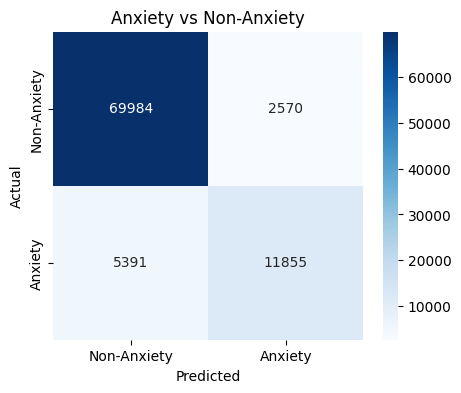

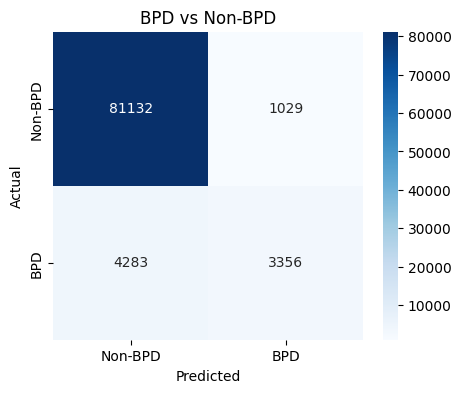

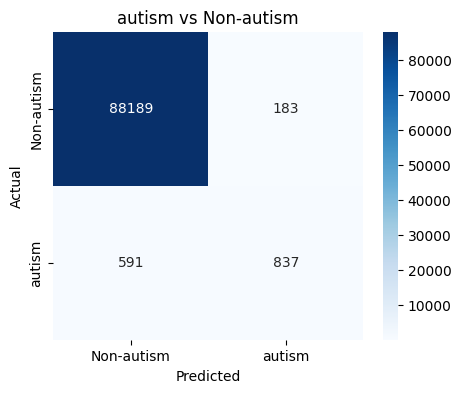

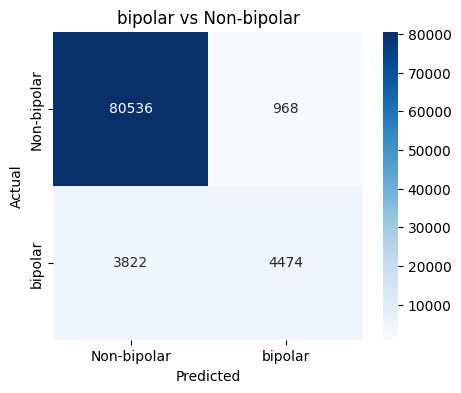

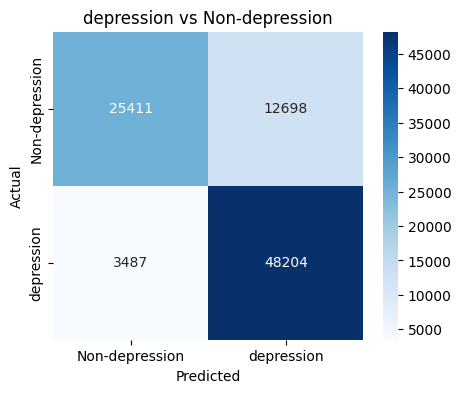

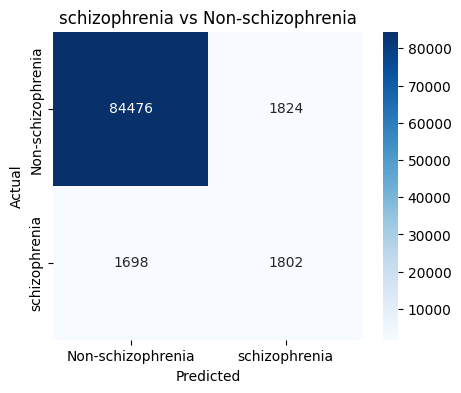

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

classes = list(le.classes_)   # correct class order

# ✅ FIX: use X_test_pad
y_pred_labels = np.argmax(model.predict(X_test_pad), axis=1)

for i, class_name in enumerate(classes):

    y_test_binary = (y_test == i).astype(int)
    y_pred_binary = (y_pred_labels == i).astype(int)

    cm = confusion_matrix(y_test_binary, y_pred_binary)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[f"Non-{class_name}", class_name],
        yticklabels=[f"Non-{class_name}", class_name]
    )

    plt.title(f"{class_name} vs Non-{class_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

classes = list(le.classes_)

y_pred_labels = np.argmax(model.predict(X_test_pad), axis=1)

for i, class_name in enumerate(classes):

    y_test_binary = (y_test == i).astype(int)
    y_pred_binary = (y_pred_labels == i).astype(int)

    precision = precision_score(y_test_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_test_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_test_binary, y_pred_binary, zero_division=0)

    print("\n==============================")
    print(f"{class_name}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

2807/2807 ━━━━━━━━━━━━━━━━━━━━ 113s 40ms/step

Anxiety
Precision : 0.8218
Recall    : 0.6874
F1 Score  : 0.7486

BPD
Precision : 0.7653
Recall    : 0.4393
F1 Score  : 0.5582

autism
Precision : 0.8206
Recall    : 0.5861
F1 Score  : 0.6838

bipolar
Precision : 0.8221
Recall    : 0.5393
F1 Score  : 0.6513

depression
Precision : 0.7915
Recall    : 0.9325
F1 Score  : 0.8563

schizophrenia
Precision : 0.4970
Recall    : 0.5149
F1 Score  : 0.5058


2807/2807 ━━━━━━━━━━━━━━━━━━━━ 112s 40ms/step


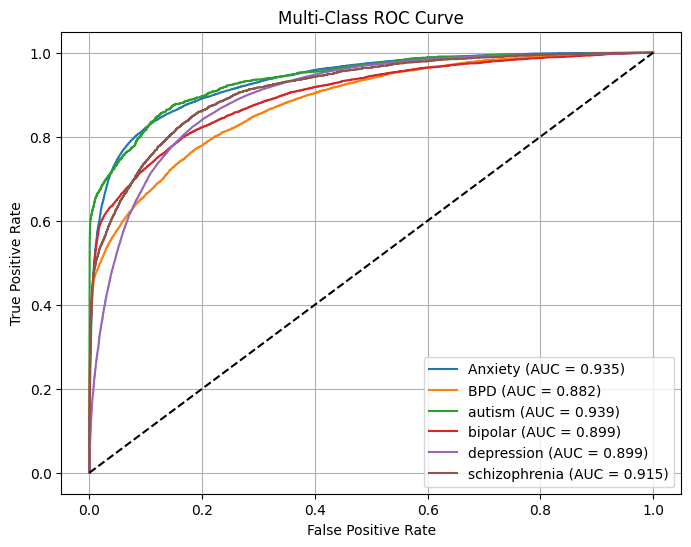

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

classes = list(le.classes_)
n_classes = len(classes)

# One-hot encoding
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# ✅ FIX
y_prob = model.predict(X_test_pad)

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

2807/2807 ━━━━━━━━━━━━━━━━━━━━ 112s 40ms/step


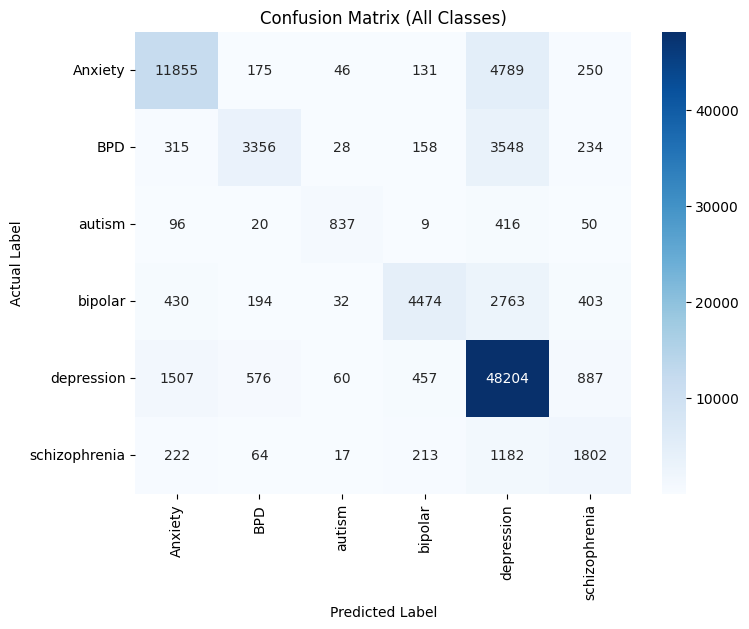

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

classes = list(le.classes_)

# ✅ FIX
y_pred = model.predict(X_test_pad)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (All Classes)")
plt.show()